In [1]:
import numpy as np
import pandas as pd
from scipy import stats

from google.colab import files
uploaded = files.upload()

Saving TeachingRatings.csv to TeachingRatings.csv


In [2]:
df = pd.read_csv("TeachingRatings.csv")

In [3]:
print(df.columns)

Index(['rownames', 'minority', 'age', 'gender', 'credits', 'beauty', 'eval',
       'division', 'native', 'tenure', 'students', 'allstudents', 'prof'],
      dtype='object')


# T-Test - Does gender affect teaching evaluation rates?

In [4]:
male_eval = df[df['gender'] == 'male']['eval']
female_eval = df[df['gender'] == 'female']['eval']

t_stat, p_value = stats.ttest_ind(male_eval, female_eval, equal_var=False)
print("Male mean evaluation: ", male_eval.mean())
print("Female mean evaluation: ", female_eval.mean())
print("T-statistic:", t_stat)
print("P-value:", p_value)

Male mean evaluation:  4.0690298507462686
Female mean evaluation:  3.901025641025641
T-statistic: 3.2667110010009375
P-value: 0.0011761043559350435


In [5]:
alpha = 0.05
if(p_value < alpha):
  print("Reject null hypothesis")
else:
  print("Fail to reject null hypothesis")

Reject null hypothesis


An independent two-sample t-test was performed to examine whether teaching evaluation scores differ by gender. Since the p-value is greater than 0.05, we fail to reject the null hypothesis. Therefore, there is insufficient statistical evidence to conclude that teaching evaluation scores differ significantly between male and female instructors.

# One-Way ANOVA - Does beauty score differ by age?

In [6]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 30, 40, np.inf],
    labels=['Young', 'Middle', 'Older']
)
df[['age', 'age_group', 'beauty']].head()

,age,age_group,beauty
0,36,Middle,0.289916
1,59,Older,-0.737732
2,51,Older,-0.571984
3,40,Middle,-0.677963
4,31,Middle,1.509794


In [7]:
young = df[df['age_group'] == 'Young']['beauty']
middle = df[df['age_group'] == 'Middle']['beauty']
older = df[df['age_group'] == 'Older']['beauty']

In [8]:
f_stat, p_stat = stats.f_oneway(young, middle, older)
print("F-statistic:", f_stat)
print("P-value:", p_stat)


F-statistic: 15.65522861587441
P-value: 2.644962177456991e-07


In [9]:
alpha = 0.05
if p_value < alpha:
  print("Reject null hypothesis")
else:
  print("Fail to reject null hypothesis")

Reject null hypothesis


The One-Way ANOVA was performed to determine whether the mean beauty scores of instructors differ across the different age groups. Since the p-value is less than the significance level of 0.05, the null hypothesis is rejected. Therefore, there is a statistically significant difference in the mean beauty scores among the age groups. This indicates that the age group of an instructor is significantly associated with differences in beauty scores.

# Two-Way ANOVA

In [21]:
df['age_group'] = pd.qcut(
    df['age'],
    q = 3,
    labels=['Young', 'Middle', 'Older']
)
print(pd.crosstab(df['age_group'], df['gender']))

gender     female  male
age_group              
Young          88    73
Middle         73    91
Older          34   104


In [22]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [23]:
anova_df = df[['beauty', 'age_group', 'gender']].dropna()
model = ols('beauty ~ C(age_group) + C(gender) + C(age_group):C(gender)', data=anova_df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                            sum_sq     df          F    PR(>F)
C(age_group)             12.905138    2.0  10.995520  0.000022
C(gender)                 1.464286    1.0   2.495221  0.114884
C(age_group):C(gender)    1.716994    2.0   1.462924  0.232640
Residual                268.184125  457.0        NaN       NaN


The Two-Way ANOVA shows that age group has a statistically significant effect on instructors' beauty scores (F = 10.9955, p < 0.05). However, gender does not have a statistically significant effect (F = 2.4952, p = 0.114884). The interaction between age group and gender is also not statistically significant (F = 1.4629, p = 0.232640). Therefore, beauty scores differ significantly across age groups, but there is insufficient evidence of an independent gender effect or an age-group × gender interaction.

One-Way ANOVA told us that beauty scores vary significantly with age group, while Two-Way ANOVA showed that this age-group difference remains significant after considering gender, whereas gender itself and the age - gender interaction are not statistically significant.

# Chi-Square - Association between tenure and gender

In [10]:
contingency_table = pd.crosstab(df['tenure'], df['gender'])
print(contingency_table)

gender  female  male
tenure              
no          50    52
yes        145   216


In [11]:
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
print("Chi-square statistic:", chi2)
print("Degrees of freedom: ", dof)
print("P-value:", p_value)

Chi-square statistic: 2.20678166999886
Degrees of freedom:  1
P-value: 0.1374050603563787


In [12]:
alpha = 0.05
if p_value < alpha:
  print("Reject null hypothesis")
else:
  print("Fail to reject null hypothesis")

Fail to reject null hypothesis


A chi-square test of independence was conducted to determine whether there is an association between tenure status and gender. Since the p-value is greater than 0.05, we fail to reject the null hypothesis. Therefore, there is insufficient statistical evidence to conclude that tenure status and gender are associated.

# Correlation - Evaluation score vs Beauty score

In [25]:
pearson_corr, pearson_p = stats.pearsonr(df['eval'], df['beauty'])
print("Pearson Correlation coefficient:", pearson_corr)
print("P-value:", pearson_p)

Pearson Correlation coefficient: 0.18903909062278274
P-value: 4.247115507786e-05


In [29]:
if abs(pearson_corr) < 0.3:
  strength = "weak"
elif abs(pearson_corr) < 0.7:
  strength = "moderate"
else:
  strength = "strong"
direction = "positive" if pearson_corr > 0 else "negative"
print(f"The pearson correlation is {strength} and {direction}.")

The pearson correlation is weak and positive.


In [30]:
alpha = 0.05
if pearson_p < alpha:
  print("The correlation is statistically significant")
else:
  print("The correlation is not statistically significant")

The correlation is statistically significant


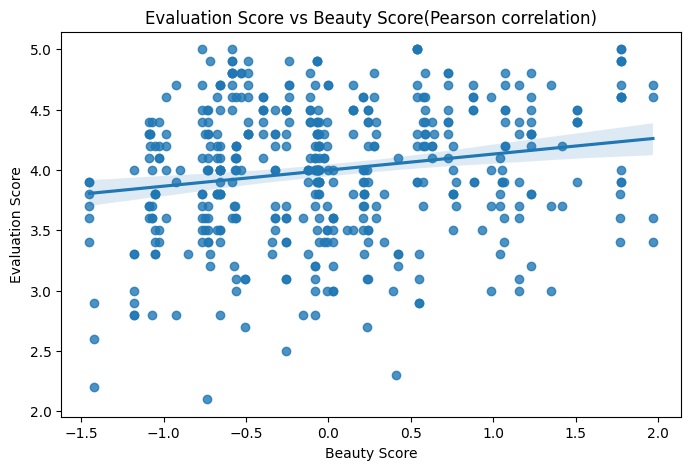

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 5))
sns.regplot(
    x=df['beauty'],
    y=df['eval'],
)

plt.xlabel('Beauty Score')
plt.ylabel('Evaluation Score')
plt.title('Evaluation Score vs Beauty Score(Pearson correlation)')
plt.show()

The Pearson correlation analysis shows a positive relationship between beauty score and teaching evaluation score. This indicates that instructors with higher beauty scores tend to have higher teaching evaluation scores. The p-value indicates whether this relationship is statistically significant at the 5% significance level.

In [28]:
spearman_corr, spearman_p = stats.spearmanr(df['eval'], df['beauty'])
print("Spearman Correlation coefficient:", spearman_corr)
print("P-value:", spearman_p)

Spearman Correlation coefficient: 0.16403522727034867
P-value: 0.0003939389405250974


In [32]:
if abs(spearman_corr) < 0.3:
  strength = "weak"
elif abs(spearman_corr) < 0.7:
  strength = "moderate"
else:
  strength = "strong"

direction = "positive" if spearman_corr > 0 else "negative"
print(f"The spearman correlation is {strength} and {direction}.")


The spearman correlation is weak and positive.


In [33]:
alpha = 0.05
if spearman_p < alpha:
  print("The correlation is statistically significant")
else:
  print("The correlation is not statistically significant")

The correlation is statistically significant


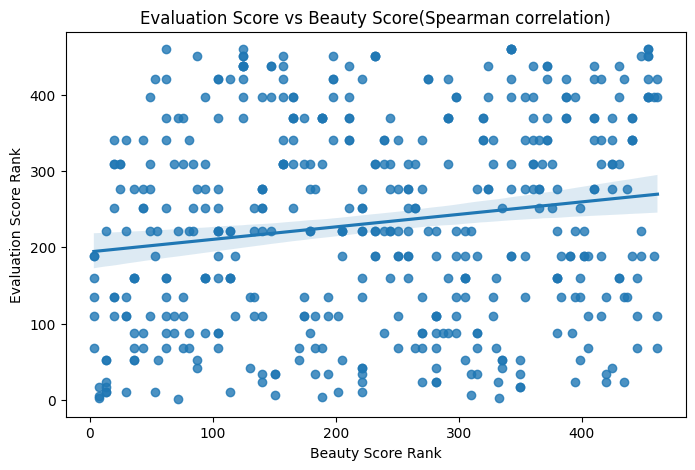

In [36]:
beauty_rank = df['beauty'].rank()
eval_rank = df['eval'].rank()
plt.figure(figsize=(8, 5))
sns.regplot(
    x=beauty_rank,
    y=eval_rank,
)

plt.xlabel('Beauty Score Rank')
plt.ylabel('Evaluation Score Rank')
plt.title('Evaluation Score vs Beauty Score(Spearman correlation)')
plt.show()

Spearman rank correlation was used to measure the monotonic relationship between instructors' beauty scores and evaluation scores. The Spearman correlation coefficient indicates the direction and strength of the relationship based on the ranks of the observations. A positive coefficient indicates that higher beauty scores tend to be associated with higher evaluation scores, while a negative coefficient indicates the opposite. The p-value is used to determine whether this relationship is statistically significant. Since the obtained p-value is less than 0.05, the correlation is considered statistically significant.

Pearson correlation uses the actual numerical values and evaluates their linear relationship, whereas Spearman correlation converts the values into ranks and evaluates their monotonic relationship. Therefore, the Pearson graph uses the original beauty and evaluation scores, while the Spearman graph uses their corresponding ranks.